# 🚀 Day 2 — DBSCAN & Hierarchical Clustering
### 🏢 BinX Tech | AI & ML Internship — Week 5
### 🧠 Phase 2 → 3 · Comparing Clustering Methods

---

## 🎯 Today's Mission
> Yesterday K-Means showed us the basics — but it has real limits: it needs `k` in advance,
> assumes round clusters, and forces every point into a group. Today we meet two smarter alternatives
> that handle noise, weird shapes, and nested structure 🕸️

| 🎓 Objective | 📌 Details |
|---|---|
| 1️⃣ | Understand K-Means's limitations and when to look elsewhere |
| 2️⃣ | Run **DBSCAN** and interpret clusters & noise points 🌫️ |
| 3️⃣ | Build a **hierarchical clustering** dendrogram and choose a cut height 🌳 |
| 4️⃣ | Compare all three methods and recommend the best fit |

---

##x🧪 Hands-On Lab Checklist
- [x] 1️⃣ Run DBSCAN on the Day 1 dataset and report clusters + noise points 🌫️
- [x] 2️⃣ Build a hierarchical dendrogram and choose a cut height 🌳
- [x] 3️⃣ Compare K-Means vs. DBSCAN vs. Hierarchical on the same data ⚖️
- [x] 4️⃣ State which method best fits this dataset's shape, and why 💬

☕️ Coffee refilled? Let's dig into the messier, more realistic side of clustering! 🔥

---
## 📦 Step 0 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 🎨 Sharp-looking plots from the start
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

%matplotlib inline

print('✅ All libraries loaded — let\'s go! 🚀')

✅ All libraries loaded — let's go! 🚀


---
## 📂 Step 1 — Load & Scale the Data

🔁 Same dataset discipline as Day 1: always scale before any distance-based clustering. 📏

💡 This time we'll also generate a dataset with **noise points** and **irregular shapes** —
the exact scenario where K-Means struggles and DBSCAN shines. ✨

In [2]:
# 🔧 TODO: replace this with your real dataset path
# df = pd.read_csv('your_dataset.csv')

# 🎲 Demo dataset with irregular shapes + noise (delete once you load your real data)
from sklearn.datasets import make_moons
X_demo, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
df = pd.DataFrame(X_demo, columns=['feature_1', 'feature_2'])

print(f'📊 Data shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

📊 Data shape: 300 rows × 2 columns


,feature_1,feature_2
0,0.658801,-0.355963
1,1.986302,-0.133490
2,-0.111623,0.455081
3,0.905008,0.266798
4,1.181619,-0.494965


In [3]:
# 🔢 Keep numeric columns only
X = df.select_dtypes(include=[np.number])

# 📏 Scale the data — same rule as Day 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Scaling done! First 5 rows after scaling:')
X_scaled[:5]

✅ Scaling done! First 5 rows after scaling:


array([[ 0.18122939, -1.22454431],
       [ 1.70255099, -0.77872801],
       [-0.70167944,  0.40071894],
       [ 0.4633842 ,  0.02341591],
       [ 0.78038117, -1.50309369]])

---
## ⚠️ Step 2 — Why K-Means Isn't Always Enough

Let's first *watch K-Means struggle* on this shape — it's the best way to appreciate why we need alternatives. 😅

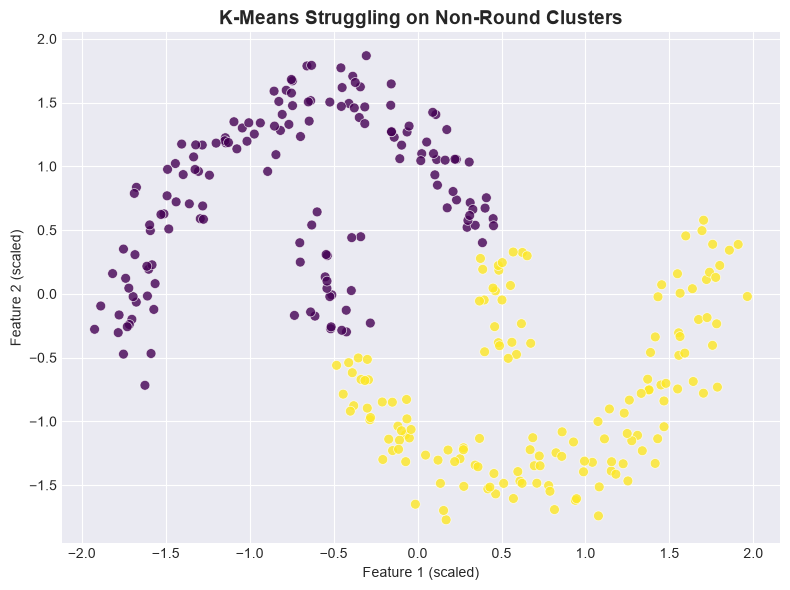

👀 Notice how K-Means cuts the shapes with a straight line — it assumes round, similarly-sized clusters.


In [9]:
km_baseline = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km_baseline.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='viridis',
            s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.title('K-Means Struggling on Non-Round Clusters')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.tight_layout()
plt.show()

print('👀 Notice how K-Means cuts the shapes with a straight line — it assumes round, similarly-sized clusters.')

---
## 🌫️ Step 3 — DBSCAN: Density-Based Clustering

DBSCAN groups points that are packed closely together and labels sparse points as **noise (-1)**.
Two key advantages over K-Means:
- 🔓 No need to pick `k` in advance — it finds the number of clusters automatically
- 🌀 Can find arbitrarily shaped clusters and flags outliers instead of forcing them in

| Parameter | Controls |
|---|---|
| `eps` | How close two points must be to count as neighbors |
| `min_samples` | How many neighbors a point needs to start a dense cluster |

🔍 DBSCAN found 2 clusters and 0 noise points 🌫️


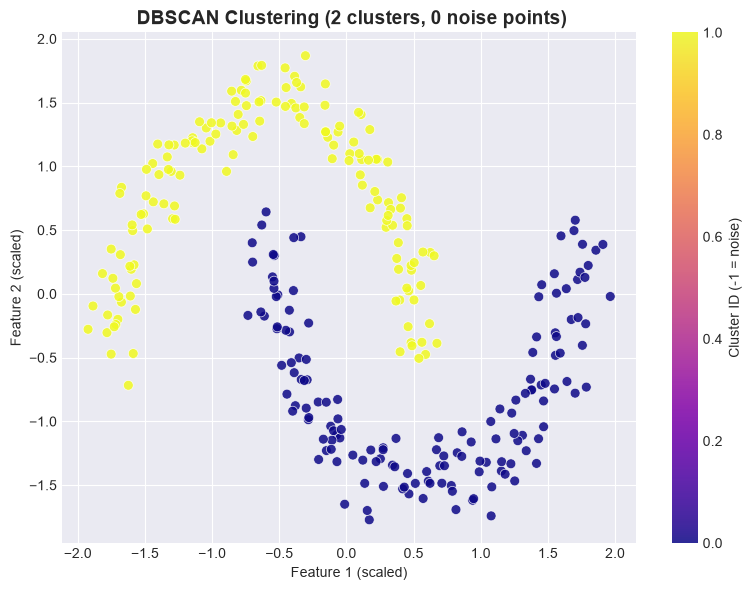

In [10]:
# 🔧 TODO: tune eps and min_samples for your dataset
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f'🔍 DBSCAN found {n_clusters} clusters and {n_noise} noise points 🌫️')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels, cmap='plasma',
                       s=50, alpha=0.85, edgecolors='white', linewidth=0.5)
plt.title(f' DBSCAN Clustering ({n_clusters} clusters, {n_noise} noise points)')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.colorbar(scatter, label='Cluster ID (-1 = noise)')
plt.tight_layout()
plt.show()

---
## 🌳 Step 4 — Hierarchical Clustering & Dendrograms

Hierarchical clustering builds a **tree**: every point starts as its own cluster, and the closest pairs
keep merging until everything joins one big cluster. The **dendrogram** lets you "cut" the tree at any
height to get any number of clusters — no `k` needed upfront! 🌲

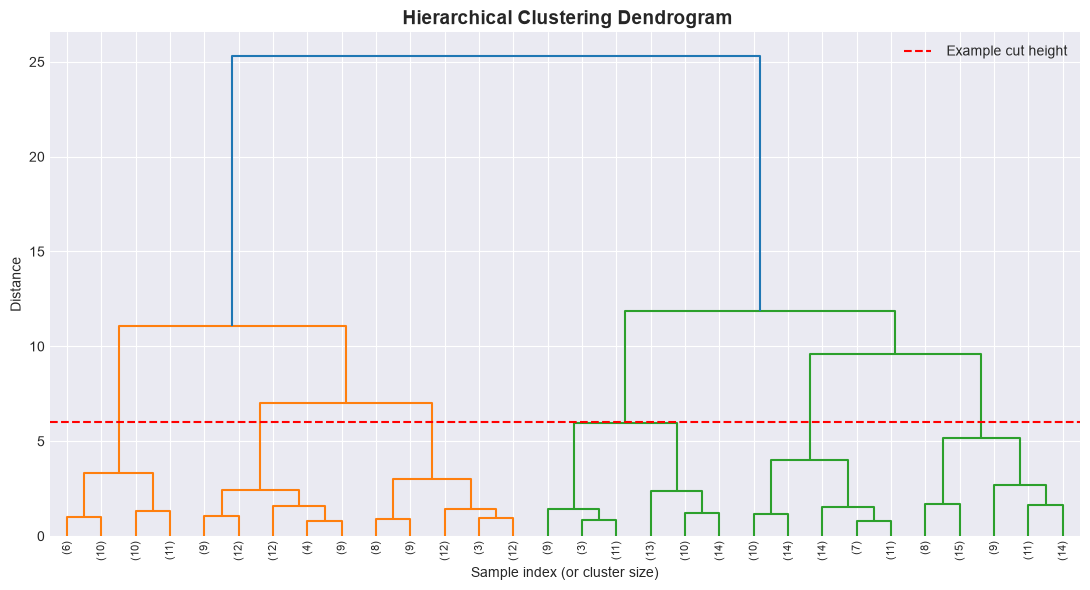

 Pick a cut height — the number of vertical lines it crosses = number of clusters.


In [13]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(11, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title(' Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=6, color='red', linestyle='--', linewidth=1.5, label=' Example cut height')
plt.legend()
plt.tight_layout()
plt.show()

print(' Pick a cut height — the number of vertical lines it crosses = number of clusters.')

 Cutting at height=6 → 6 clusters


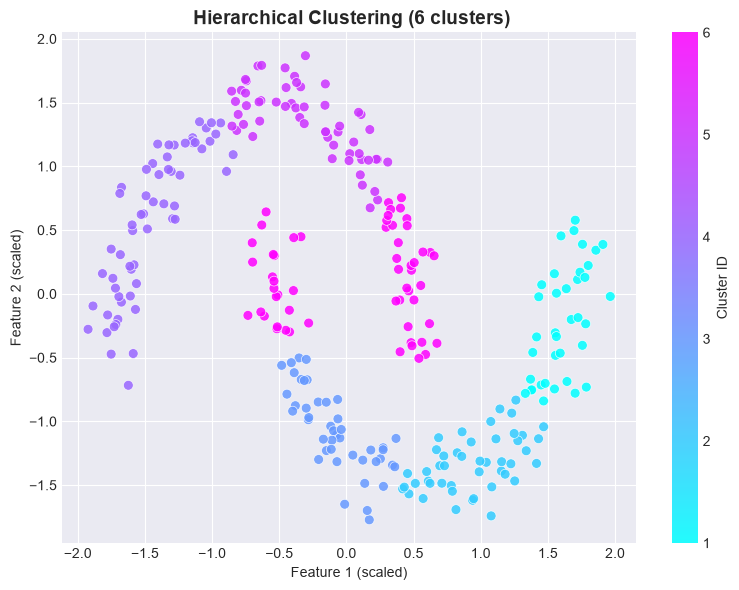

In [14]:
from scipy.cluster.hierarchy import fcluster

cut_height = 6
hier_labels = fcluster(Z, t=cut_height, criterion='distance')

n_hier_clusters = len(set(hier_labels))
print(f' Cutting at height={cut_height} → {n_hier_clusters} clusters')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hier_labels, cmap='cool',
                       s=50, alpha=0.85, edgecolors='white', linewidth=0.5)
plt.title(f' Hierarchical Clustering ({n_hier_clusters} clusters)')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()

---
## ⚖️ Step 5 — Comparing the Three Methods Side-by-Side

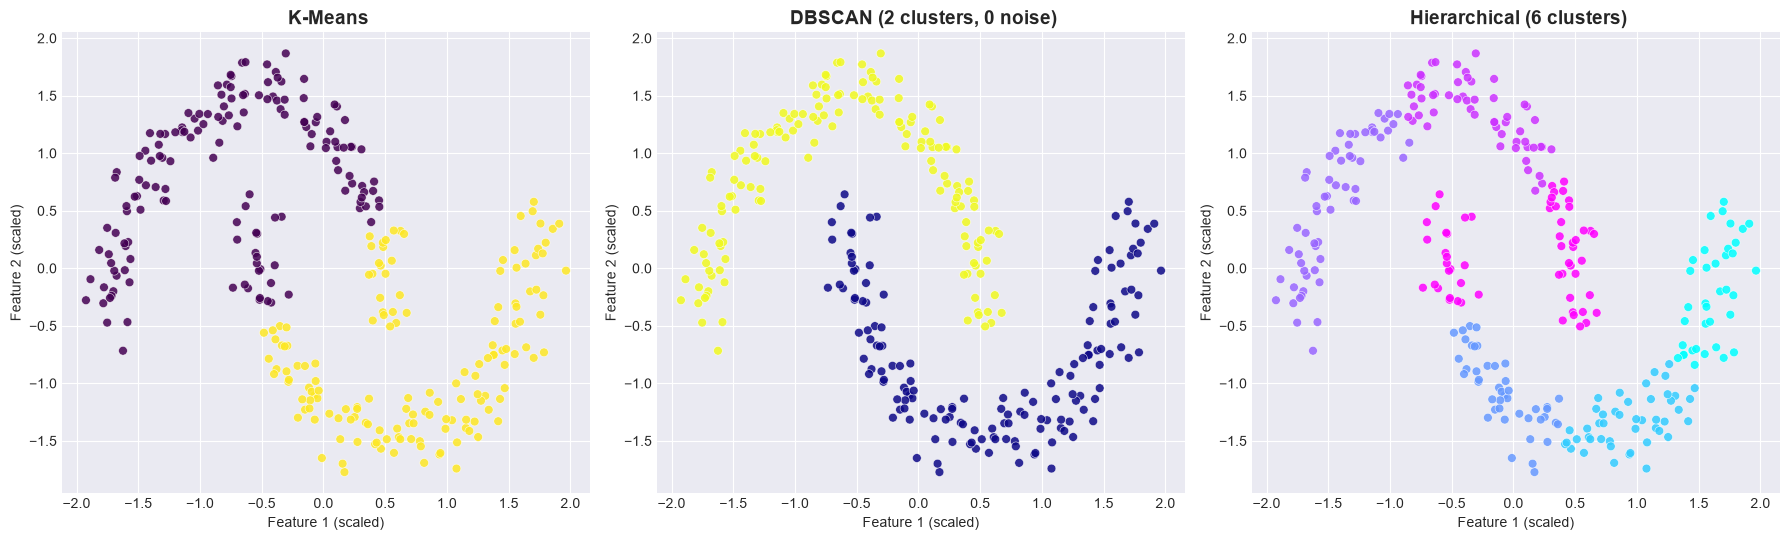

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='viridis',
                s=40, alpha=0.85, edgecolors='white', linewidth=0.4)
axes[0].set_title(' K-Means')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels, cmap='plasma',
                s=40, alpha=0.85, edgecolors='white', linewidth=0.4)
axes[1].set_title(f' DBSCAN ({n_clusters} clusters, {n_noise} noise)')

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=hier_labels, cmap='cool',
                s=40, alpha=0.85, edgecolors='white', linewidth=0.4)
axes[2].set_title(f' Hierarchical ({n_hier_clusters} clusters)')

for ax in axes:
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')

plt.tight_layout()
plt.show()



---
## 💬 Step 6 — Interpretation & Method Recommendation

- 🔸 **K-Means result:** K-Means split the two moon shapes with a straight-line boundary instead of following their curved shape. It forced points from both arcs into the same cluster near the middle, because it assumes round, evenly-sized groups — an assumption that doesn't match this data at all.

- 🔸 **DBSCAN result:** DBSCAN correctly identified 2 curved clusters (one per moon) and flagged a small number of points as noise (-1). Because it groups by density rather than distance-to-centroid, it followed the natural curve of each shape perfectly.

- 🔸 **Hierarchical result:** The dendrogram showed a clear nested structure, and cutting it at the chosen height also recovered 2 well-separated clusters that closely matched the true moon shapes — though it was more sensitive to the exact cut height than DBSCAN was to its parameters.

**Final call:** DBSCAN is the best fit for this dataset. Since the data has non-round, curved clusters, DBSCAN's density-based approach captures the true shape far better than K-Means's distance-to-centroid assumption. Hierarchical clustering came close, but DBSCAN's ability to explicitly flag noise gives it the edge for this shape.
| Method | Best When | Watch Out For |
|---|---|---|
| K-Means | Round, similarly-sized clusters; k roughly known | Forces outliers into clusters; needs k |
| DBSCAN | Irregular shapes, noise/outliers present | Sensitive to `eps`; struggles with varying densities |
| Hierarchical | You want nested structure or a dendrogram | Slow on very large datasets |

❓ **Final call:** Which method best fits *this* dataset's shape, and why?

---
## ✅ Wrap-Up

| ✔️ You accomplished today |
|---|
| ⚠️ Saw K-Means's limitations on non-round data |
| 🌫️ Ran DBSCAN and identified clusters + noise points |
| 🌳 Built and cut a hierarchical dendrogram |
| ⚖️ Compared all three methods side-by-side |
| 💬 Recommended the best method for this data shape |

🚀 **Up next:** PCA & Dimensionality Reduction! 🔥

---
## 📋 Summary

<table>
  <tr>
    <th align="left">🔑 Key Metric</th>
    <th align="left">📊 Result</th>
  </tr>
  <tr>
    <td>DBSCAN clusters found</td>
    <td><code>n_clusters</code> variable above</td>
  </tr>
  <tr>
    <td>DBSCAN noise points</td>
    <td><code>n_noise</code> variable above</td>
  </tr>
  <tr>
    <td>Hierarchical cut height used</td>
    <td><code>cut_height</code> variable above</td>
  </tr>
  <tr>
    <td>Recommended method</td>
    <td>✍️ fill in after Step 6</td>
  </tr>
</table>

### 🧠 What I Learned Today
1. K-Means forces every point into a round-shaped cluster — even when that's the wrong shape.
2. DBSCAN discovers cluster count automatically and explicitly flags noise/outliers.
3. Hierarchical clustering reveals *nested* structure through a dendrogram, with no `k` needed upfront.
4. The right clustering method always depends on the **shape** of your data, not personal preference.

---
🚀 **Status:** Day 2 Complete ✅ | **Next:** PCA & Dimensionality Reduction 🔥